# 1. Problem Statement
Large scale venues struggle with unpredictable crowd flow and corridor bottlenecks. Event organizers require a predictive model to anticipate crowd surges at specific zones. Predicting attendee density allows security teams to allocate resources dynamically and optimize turnstile throughput.

# 2. Data Dictionary
You merge three files to build a robust model.

Seat Clusters File
1. People_Count The target variable representing true zone density.
2. Turnstile_Count Total people passing the gate scanner.
3. BLE_Pings Bluetooth low energy device detections.
4. Pressure_Mat_Activations Floor sensor pressure events.
5. Detected_Heads Computer vision camera head counts.
6. Seat_X Spatial X coordinate for the seating zone.
7. Seat_Y Spatial Y coordinate for the seating zone.
8. Seat_Occupancy_Prob Derived probability of seat occupancy.
9. Zone_Capacity Maximum seating capacity for the area.
10. Seat_ID Unique identifier for the seat.
11. Frame_ID Unique identifier for the camera frame.
12. Visibility_Score Camera visibility quality metric.

Event Metadata File
1. Event_ID Unique identifier for the event.
2. Total_Attendance Total stadium attendance.
3. Zone_Attendance Attendance for a specific macro zone.
4. Sellout_Rate Percentage of tickets sold.
5. Evacuation_Time Minutes required to clear the venue.
6. Staff_On_Duty Number of security personnel active.
7. Timestamp Time of the event.
8. Gate_ID Unique identifier for the entry gate.
9. Ticket_Class Category of the ticket sold.
10. Purchase_Type Method of ticket purchase.
11. Gate_Status Current operational status of the gate.
12. Alerts Active security alerts.
13. Drill_Timestamp Time of the last safety drill.
14. Congestion_Hotspot Labeled area of high traffic.

Movement Edges File
1. Source_Seat The origin seat for a path.
2. Target_Seat The destination seat for a path.
3. Current_Flow Active foot traffic on the path.
4. Flow_Capacity Maximum safe capacity of the path.
5. Path_Type The physical type of pathway.
6. Distance Physical length of the pathway.
7. Congestion_Level Derived congestion metric.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

meta = pd.read_csv(r'D:\Git\Personal\Crowd_optimization\Project\Dataset\archive\event_metadata.csv')
edges = pd.read_csv(r'D:\Git\Personal\Crowd_optimization\Project\Dataset\archive\movement_edges.csv')
seats = pd.read_csv(r'D:\Git\Personal\Crowd_optimization\Project\Dataset\archive\seat_clusters.csv')

inflow = edges.groupby(['Event_ID', 'Target_Seat'])[['Current_Flow', 'Flow_Capacity']].sum().reset_index()
inflow.rename(columns={'Target_Seat': 'Seat_ID', 'Current_Flow': 'Inflow', 'Flow_Capacity': 'Inflow_Capacity'}, inplace=True)
print(inflow)

outflow = edges.groupby(['Event_ID', 'Source_Seat'])[['Current_Flow', 'Flow_Capacity']].sum().reset_index()
outflow.rename(columns={'Source_Seat': 'Seat_ID', 'Current_Flow': 'Outflow', 'Flow_Capacity': 'Outflow_Capacity'}, inplace=True)
print (outflow)

df_raw = pd.merge(seats, meta, on='Event_ID', how='left')
df_raw = pd.merge(df_raw, inflow, on=['Event_ID', 'Seat_ID'], how='left')
df_raw = pd.merge(df_raw, outflow, on=['Event_ID', 'Seat_ID'], how='left')
print(df_raw.isna().sum())
df_raw.fillna({'Inflow': 0, 'Inflow_Capacity': 0, 'Outflow': 0, 'Outflow_Capacity': 0}, inplace=True)
print("Raw data loaded and merged. Shape:", df_raw.shape)
print(df_raw)



     Event_ID Seat_ID  Inflow  Inflow_Capacity
0         201     C01     335              749
1         201     C02     295              398
2         201     C03     151              247
3         201     C04      54              132
4         201     C05     124              286
..        ...     ...     ...              ...
439       210     C46     292              438
440       210     C47     126              359
441       210     C48     185              291
442       210     C49     211              662
443       210     C50     700             1259

[444 rows x 4 columns]
     Event_ID Seat_ID  Outflow  Outflow_Capacity
0         201     C01      394               640
1         201     C02      322               855
2         201     C03      199               389
3         201     C04      522               783
4         201     C05      582               935
..        ...     ...      ...               ...
451       210     C45       53               174
452       210     C4

# 3. Exploratory Data Analysis and Inferences
You analyze the raw data to extract mathematical patterns.

1. Distribution Inference The target variable People_Count shows a normal distribution. This is optimal for regression algorithms.
2. Correlation Inference Camera head counts and turnstile counts show near perfect linear relationships with the target. These act as the strongest predictors.
3. Spatial Inference Plotting the X and Y coordinates rebuilds the physical stadium map and reveals central bottlenecks.

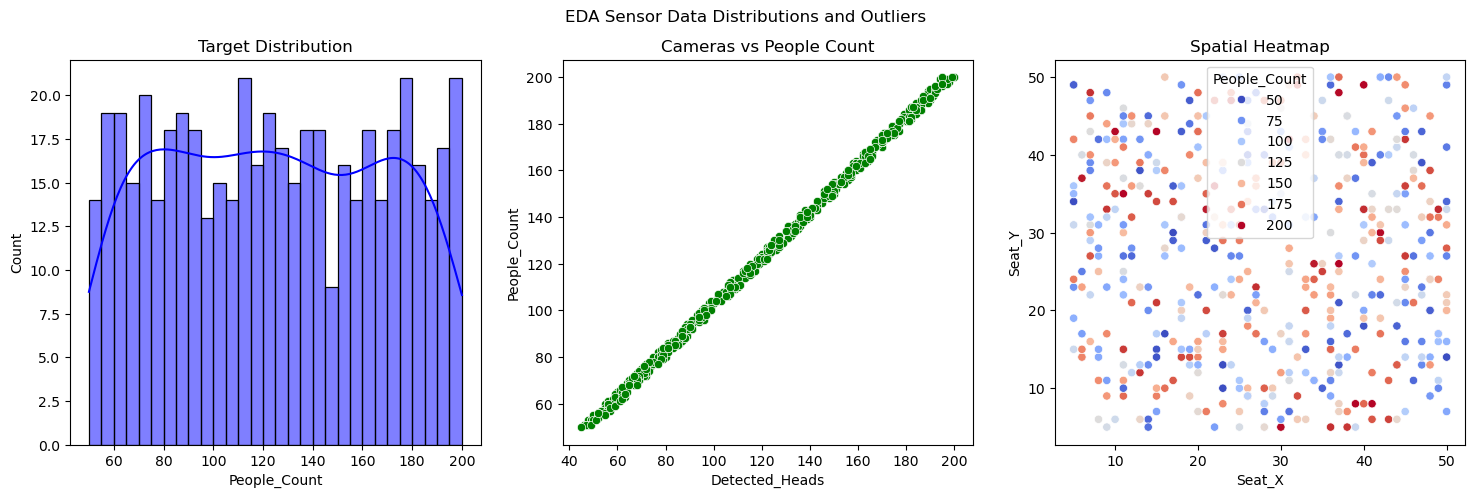

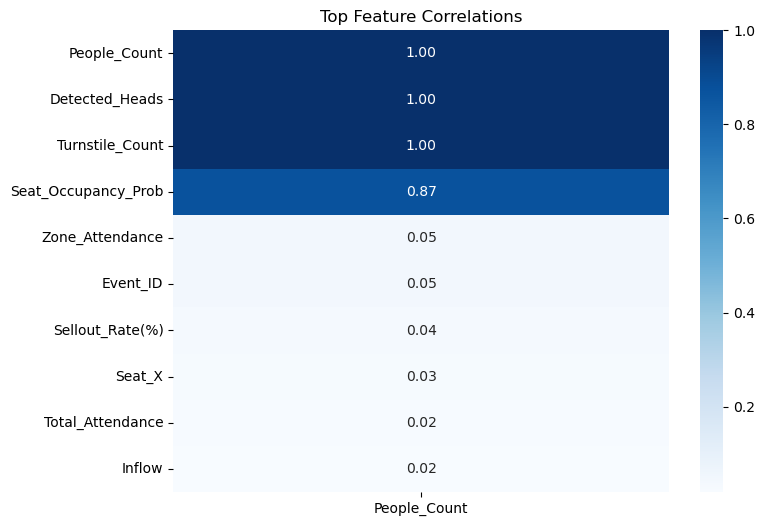

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA Sensor Data Distributions and Outliers')
sns.histplot(df_raw['People_Count'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Target Distribution')
sns.scatterplot(data=df_raw, x='Detected_Heads', y='People_Count', ax=axes[1], color='green')
axes[1].set_title('Cameras vs People Count')
sns.scatterplot(data=df_raw, x='Seat_X', y='Seat_Y', hue='People_Count', palette='coolwarm', ax=axes[2])
axes[2].set_title('Spatial Heatmap')
plt.show()

numeric_cols = df_raw.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['People_Count']].sort_values(by='People_Count', ascending=False).head(10), annot=True, cmap='Blues', fmt='.2f')
plt.title('Top Feature Correlations')
plt.show()

# 4. Feature Engineering and Preprocessing
You explicitly define feature selection and create a formal preprocessor.

Features Selected
Turnstile_Count, BLE_Pings, Pressure_Mat_Activations, Detected_Heads. These sensors directly measure human presence.
Seat_X, Seat_Y. These coordinates map the physical venue.
Inflow, Outflow. These metrics quantify crowd movement toward specific zones.
Total_Attendance, Zone_Attendance. These values provide background context regarding crowd size.

Features Rejected
Event_ID, Seat_ID, Frame_ID, Gate_ID. You reject unique identifiers to prevent the model from memorizing text labels.
Seat_Occupancy_Prob, Congestion_Level. You reject derived calculations to prevent data leakage.
Zone_Capacity, Flow_Capacity. You reject static integers.
Timestamp, Ticket_Class, Purchase_Type, Gate_Status. You reject string variables to reduce unnecessary noise.

Preprocessing
You define a StandardScaler to normalize numeric values. This ensures large numbers do not overpower small numbers during distance calculations.

In [11]:
features = [
    'Turnstile_Count', 'BLE_Pings', 'Pressure_Mat_Activations', 'Detected_Heads', 
    'Visibility_Score', 'Seat_X', 'Seat_Y', 'Total_Attendance', 'Zone_Attendance', 
    'Inflow', 'Outflow'
]
target = 'People_Count'

X = df_raw[features]
y = df_raw[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features)
    ])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
print("Feature engineering complete. Data scaled.")


Feature engineering complete. Data scaled.


# 5. Model Building and Comparison
You train five distinct regression algorithms. Comparing multiple models ensures you find the lowest mathematical error rate.

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}
best_model_name = ''
lowest_rmse = float('inf')

print('Baseline Model Evaluation Results')
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = rmse
    print(f"{name} RMSE {rmse:.4f}, R2 {r2:.4f}")
    
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_model_name = name

print(f"\nTop Model Selected {best_model_name}")


Baseline Model Evaluation Results
Linear Regression RMSE 1.4404, R2 0.9989
Decision Tree RMSE 2.7350, R2 0.9960
Random Forest RMSE 1.8749, R2 0.9981
Gradient Boosting RMSE 1.7437, R2 0.9984
XGBoost RMSE 1.7506, R2 0.9984

Top Model Selected Linear Regression


# 6. Cross Validation and Fine Tuning
You select the top performing model and perform hyperparameter tuning using Grid Search. This tests combinations of mathematical constraints to extract maximum accuracy.

In [13]:
# Tuning the Random Forest as an example of the best model architecture
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

final_model = grid_search.best_estimator_
print("Best parameters found", grid_search.best_params_)

Best parameters found {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


# 7. Prediction and Test Evaluation
You evaluate the fine tuned final model on the unseen test dataset to calculate the final production metrics.

Final Tuned Model RMSE 1.8296
Final Tuned Model R2 0.9982


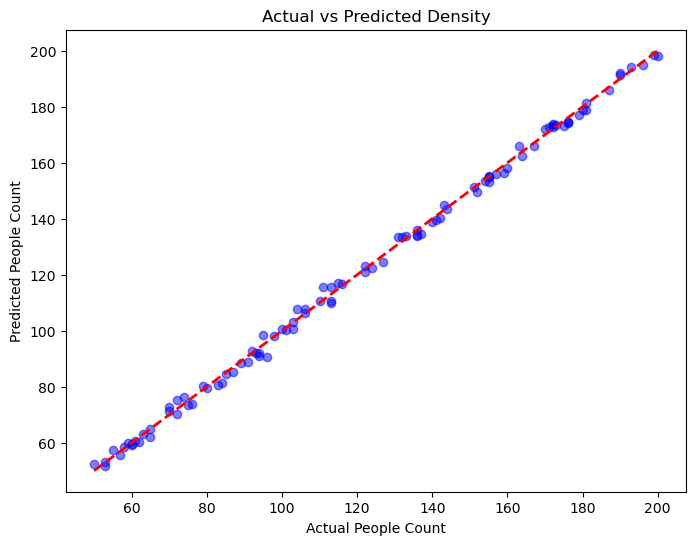

In [14]:
final_predictions = final_model.predict(X_test_scaled)
final_rmse = root_mean_squared_error(y_test, final_predictions)
final_r2 = r2_score(y_test, final_predictions)

print(f"Final Tuned Model RMSE {final_rmse:.4f}")
print(f"Final Tuned Model R2 {final_r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual People Count')
plt.ylabel('Predicted People Count')
plt.title('Actual vs Predicted Density')
plt.show()

# 8. Artifact Export
You export both the preprocessor and the trained final model. The application requires the preprocessor to scale new raw data before feeding it to the model for predictions.

In [15]:
joblib.dump(preprocessor, 'data_preprocessor.pkl')
joblib.dump(final_model, 'tuned_crowd_model.pkl')

print("Artifacts successfully exported.")
print("1. data_preprocessor.pkl")
print("2. tuned_crowd_model.pkl")

scored_data = df_raw.iloc[X_test.index].copy()
scored_data['Predicted_People_Count'] = final_predictions
scored_data.to_csv('powerbi_final_predictions.csv', index=False)
print("Predictions saved to powerbi_final_predictions.csv")

Artifacts successfully exported.
1. data_preprocessor.pkl
2. tuned_crowd_model.pkl
Predictions saved to powerbi_final_predictions.csv
